In [162]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import warnings
import pickle
import random
import tqdm

In [186]:
import seaborn as sns

In [5]:
import rubinml
import LensCalcPy

In [9]:
%reload_ext autoreload
%autoreload 2

In [3]:
basedir = '/Volumes/thesis/rubin-sim/userdata/opsim_ml/'
sources = pd.read_parquet(basedir+"rand_tristar_10_000_000.parquet")

In [6]:
mw = LensCalcPy.galaxy.MilkyWayModel()

In [14]:
%%prun -s cumtime
rates = rubinml.events.calculate_lensing_rates(sources, mw, basedir+'/rates/test', n_sources=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

         73350532 function calls (71287465 primitive calls) in 42.354 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   42.354   42.354 {built-in method builtins.exec}
        1    0.010    0.010   42.354   42.354 <string>:1(<module>)
        1    0.049    0.049   42.343   42.343 events.py:52(calculate_lensing_rates)
     1000    0.003    0.000   41.758    0.042 events.py:43(source_lensing_rate)
     1000    0.004    0.000   41.755    0.042 pbh.py:315(rate_total)
495361/1000    0.879    0.000   38.818    0.039 _quadpack_py.py:968(nquad)
516361/1000    1.045    0.000   38.811    0.039 _quadpack_py.py:1254(integrate)
516361/1000    1.086    0.000   38.805    0.039 _quadpack_py.py:22(quad)
516361/1000    0.722    0.000   38.803    0.039 _quadpack_py.py:593(_quad)
22000/1000    0.309    0.000   38.780    0.039 {built-in method scipy.integrate._quadpack._qagpe}
   494361    0.396    0.000   38.075  

In [21]:
np.sum(np.array(list(rates.values())))

1.316142131277614e-07

In [25]:
rates

{(277.0667334398, -31.4721414675, 18.492000579833984): 1.5793342739054587e-10,
 (345.6644296646119,
  -6.2229778315622895,
  9.399999618530273): 7.010172488238033e-13,
 (308.41232299804693,
  -12.57037272579825,
  10.850000381469727): 2.6669698196442804e-12,
 (257.7252781391144,
  7.877430624422416,
  13.050000190734863): 1.573043435157606e-11,
 (310.7943230867386,
  21.979896511965293,
  11.350000381469727): 4.475173943927727e-12,
 (266.06038749217987,
  4.238828819894337,
  14.600000381469727): 3.5030296901276735e-11,
 (191.90047860145572, 22.863231596587458, 12.75): 1.081139183919056e-11,
 (8.147858977317808,
  3.939934297410971,
  14.699999809265137): 1.7817719727234356e-10,
 (331.76340937614435,
  -11.726331409559322,
  15.600000381469727): 1.5811265846107146e-10,
 (63.9707601070404,
  3.539227363015627,
  13.949999809265137): 3.555801566756147e-11,
 (9.64766442775726,
  2.337082705378947,
  16.850000381469727): 6.483916389519303e-10,
 (53.145487904548645,
  -9.024365333133431,
  

In [ ]:
np.sum(np.array(list(rates.values())))

1.316142131277614e-07

In [29]:
%%prun -s cumtime
rates = rubinml.events.calculate_lensing_rates(sources, mw, basedir+'/rates/test', n_sources=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [46]:
%%prun -s cumtime
rate1=[]
rate2=[]
n_rates = 1000
sources_arr=sources.iloc[:1000][['gall','galb','mu0']].to_numpy()
for i in tqdm.tqdm(range(n_rates)):
  l,b,mu0=sources_arr[i]
  ds = rubinml.events.kpc_from_mu0(mu0)
  args = (ds, 1, 5, 
              rubinml.events.differential_rate_integrand_mw_maker(l, b, ds, 5, 1, mw))

  with warnings.catch_warnings(action="ignore"):
    rate1.append(LensCalcPy.pbh.rate_total(*args))
    rate2.append(LensCalcPy.pbh.rate_total_2(*args)[0])

100%|██████████| 1000/1000 [01:12<00:00, 13.79it/s]

         114358467 function calls (110208428 primitive calls) in 72.498 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   72.498   72.498 {built-in method builtins.exec}
        1    0.019    0.019   72.498   72.498 <string>:1(<module>)
475193/2000    0.855    0.000   66.234    0.033 _quadpack_py.py:968(nquad)
1039505/2000    2.254    0.000   66.220    0.033 _quadpack_py.py:1254(integrate)
1039505/2000    1.684    0.000   66.210    0.033 _quadpack_py.py:22(quad)
1039505/2000    2.934    0.000   66.206    0.033 _quadpack_py.py:593(_quad)
566312/2000    4.120    0.000   66.170    0.033 {built-in method scipy.integrate._quadpack._qagpe}
     1000    0.004    0.000   40.371    0.040 pbh.py:315(rate_total)
   473193    0.365    0.000   36.619    0.000 pbh.py:323(integrand)
     1000    0.003    0.000   31.827    0.032 pbh.py:344(rate_total_2)
 22218231   26.879    0.000   31.690    0.000 events.py:3

In [47]:
rate1=np.array(rate1)
rate2=np.array(rate2)

In [44]:
rate1-rate2

array([ 0.00000000e+000, -2.46987101e-025,  0.00000000e+000,
       -7.35758537e-092, -1.10695429e-054, -9.25559641e-061,
       -6.87920682e-041, -7.09760521e-025, -1.85556833e-027,
       -4.84886641e-119])

/var/folders/5s/5m5dcls13_scn11gch5x16680000gn/T/ipykernel_86957/846475026.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(rate1),np.log10(rate2))


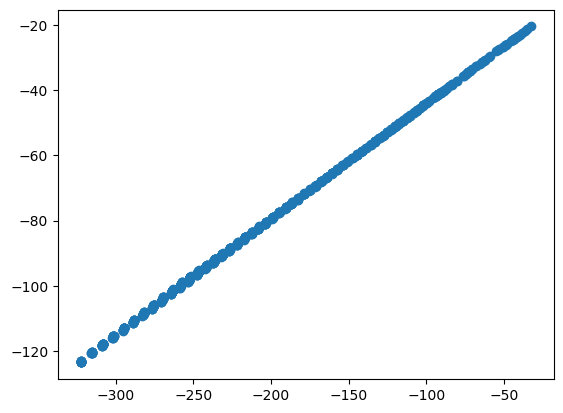

In [51]:
plt.scatter(np.log10(rate1),np.log10(rate2))


True

(array([  1.,   0.,   1.,   0.,   1.,   1.,   0.,   1.,   2.,   1.,   3.,
          2.,   0.,   1.,   4.,   0.,   1.,   2.,   0.,   1.,   1.,   3.,
          3.,   2.,   2.,   6.,   5.,   0.,   2.,   5.,   5.,  11.,   6.,
          8.,   6.,  11.,  13.,  17.,  16.,  11.,  14.,  19.,  29.,  27.,
         35.,  37.,  67.,  97., 141., 104.]),
 array([1.57050729, 1.59153407, 1.61256085, 1.63358763, 1.65461441,
        1.67564119, 1.69666797, 1.71769475, 1.73872153, 1.75974831,
        1.78077509, 1.80180187, 1.82282865, 1.84385543, 1.86488221,
        1.88590899, 1.90693577, 1.92796255, 1.94898933, 1.97001611,
        1.99104289, 2.01206967, 2.03309645, 2.05412323, 2.07515001,
        2.09617679, 2.11720357, 2.13823035, 2.15925713, 2.18028391,
        2.20131069, 2.22233747, 2.24336425, 2.26439103, 2.28541781,
        2.30644459, 2.32747137, 2.34849815, 2.36952493, 2.39055171,
        2.41157849, 2.43260527, 2.45363205, 2.47465883, 2.49568561,
        2.51671239, 2.53773917, 2.55876595, 2.

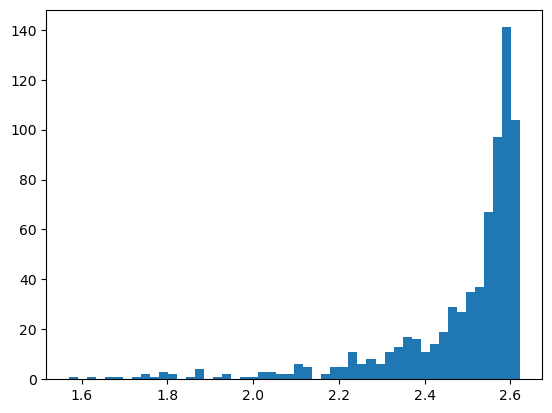

In [58]:
mask = (rate1 >0 ) &( rate2 >0)
plt.hist(np.log10(rate1[mask])/np.log10(rate2[mask]), bins=50)


In [60]:
len(rates)

1000

In [202]:
full_rates_file = ('/Volumes/thesis/rubin-sim/userdata/opsim_ml/'
                  'ml_events_336265_toss-20000_1721087495'
                  '_full_ut-5_m-1.pickle')
with open(full_rates_file,'rb') as f:
  rates = pickle.load(f)

In [80]:
full_rates_csv = ('/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates_ml_rates_1718083107_te-True_ut-5.csv')
rates = rubinml.load_rates_from_file(full_rates_csv)

opened /Volumes/thesis/rubin-sim/userdata/opsim_ml/rates_ml_rates_1718083107_te-True_ut-5.csv


In [1]:
rates

NameError: name 'rates' is not defined

In [113]:
fullrate = rubinml.events.rates_to_rubin_counts(rates)

array([1.00000000e-06, 1.22167735e-06, 1.49249555e-06, 1.82334800e-06,
       2.22754295e-06, 2.72133877e-06, 3.32459793e-06, 4.06158599e-06,
       4.96194760e-06, 6.06189899e-06, 7.40568469e-06, 9.04735724e-06,
       1.10529514e-05, 1.35031404e-05, 1.64964807e-05, 2.01533769e-05,
       2.46209240e-05, 3.00788252e-05, 3.67466194e-05, 4.48925126e-05,
       5.48441658e-05, 6.70018750e-05, 8.18546731e-05, 1.00000000e-04,
       1.22167735e-04, 1.49249555e-04, 1.82334800e-04, 2.22754295e-04,
       2.72133877e-04, 3.32459793e-04, 4.06158599e-04, 4.96194760e-04,
       6.06189899e-04, 7.40568469e-04, 9.04735724e-04, 1.10529514e-03,
       1.35031404e-03, 1.64964807e-03, 2.01533769e-03, 2.46209240e-03,
       3.00788252e-03, 3.67466194e-03, 4.48925126e-03, 5.48441658e-03,
       6.70018750e-03, 8.18546731e-03, 1.00000000e-02, 1.22167735e-02,
       1.49249555e-02, 1.82334800e-02, 2.22754295e-02, 2.72133877e-02,
       3.32459793e-02, 4.06158599e-02, 4.96194760e-02, 6.06189899e-02,
      

In [136]:

fracs = np.logspace(-5,-2,70)
fractional_rates = []
for frac in tqdm.tqdm(fracs):
  this_fractional_rates=[]
  for i in range(200):
    rates_subset = dict(random.sample(list(rates.items()), int(len(rates)*frac)))
    this_fractional_rates.append(rubinml.events.rates_to_rubin_counts(rates_subset))
  fractional_rates.append(this_fractional_rates)

100%|██████████| 70/70 [05:24<00:00,  4.64s/it]


In [125]:
errs = np.array([np.std(rs) for rs in fractional_rates])
res_abs = np.array([np.mean(np.abs(np.array(rs)-fullrate)) for rs in fractional_rates])
res = np.array([np.mean(np.array(rs)-fullrate) for rs in fractional_rates])

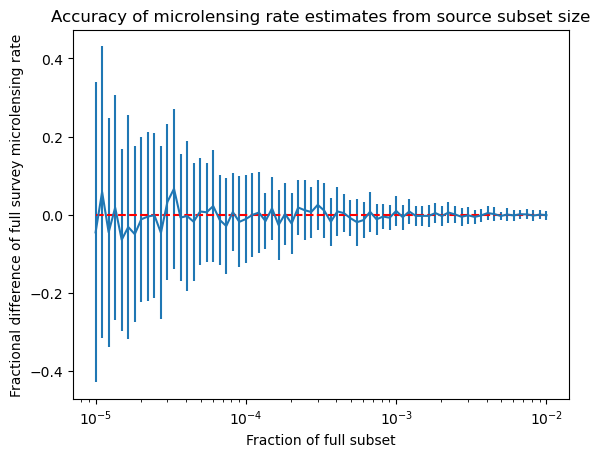

In [137]:
plt.errorbar(fracs, res/fullrate, res_abs/fullrate)
plt.hlines(0, min(fracs), max(fracs), linestyles='dashed',colors='red')
plt.xscale('log')
plt.title('Accuracy of microlensing rate estimates from source subset size')
plt.xlabel('Fraction of full subset')
plt.ylabel('Fractional difference of full survey microlensing rate')
plt.savefig('/Users/duncan/Documents/code/physics/dissertation/ims/rubinsim/rate_accuracy.pdf')

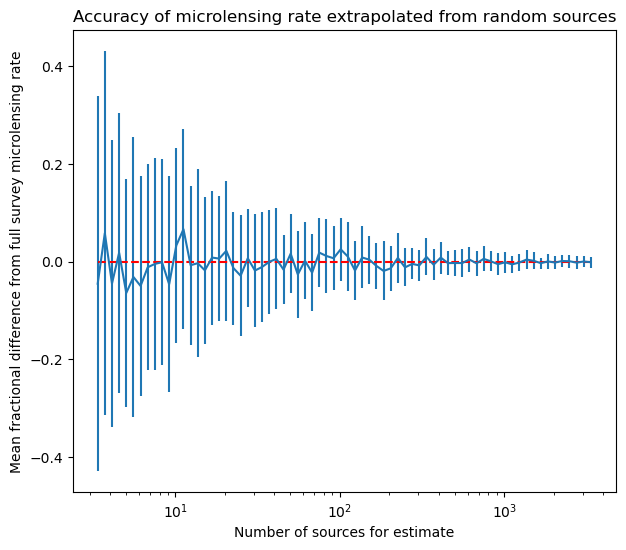

In [212]:
fig = plt.figure(figsize=(7,6))
plt.errorbar(fracs*len(rates), res/fullrate, res_abs/fullrate)
plt.hlines(0, min(fracs)*len(rates), max(fracs)*len(rates), linestyles='dashed',colors='red')
plt.xscale('log')
plt.title('Accuracy of microlensing rate extrapolated from random sources')
plt.xlabel('Number of sources for estimate')
plt.ylabel('Mean fractional difference from full survey microlensing rate')
# plt.tight_layout()
plt.savefig('/Users/duncan/Documents/code/physics/dissertation/ims/rubinsim/rate_accuracy_nsources.pdf')

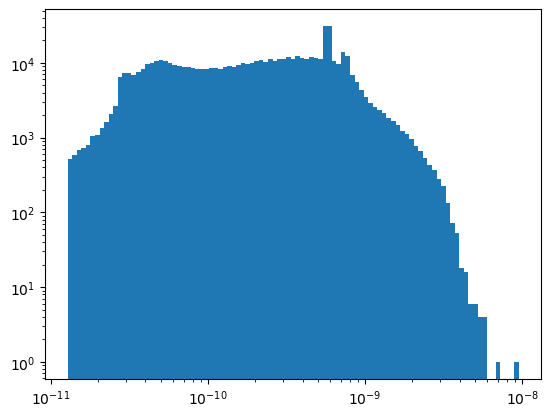

In [144]:
plt.hist(rates.values(), bins=np.geomspace(*np.percentile(np.array(list(rates.values())), (1,100)),100))
plt.xscale('log')
plt.yscale('log')

In [159]:
len(rates)

604308

Text(0.5, 1.0, 'Fractional distance of each ')

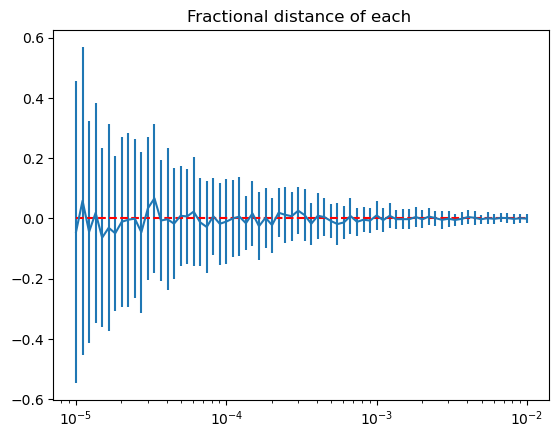

In [132]:
plt.errorbar(fracs, res/fullrate, errs/fullrate)
plt.hlines(0, min(fracs), max(fracs), linestyles='dashed',colors='red')
plt.xscale('log')
plt.title('Fractional distance of each ')

Text(0.5, 1.0, 'Fractional distance of each ')

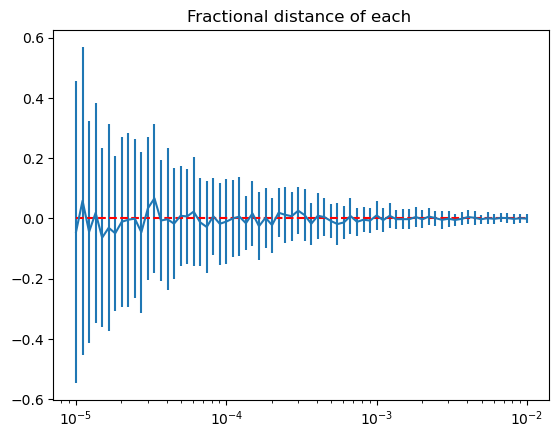

In [ ]:
plt.errorbar(fracs*len(rates), res/fullrate, errs/fullrate)
plt.hlines(0, min(fracs), max(fracs), linestyles='dashed',colors='red')
plt.xscale('log')
plt.title('Fractional distance of each ')

In [103]:
print(np.std(half_sub_rates)/rubinml.events.rates_to_rubin_counts(rates_subset))
print(np.mean(half_sub_rates)/rubinml.events.rates_to_rubin_counts(rates_subset))

0.15237225747505198
1.0410104724298848


In [145]:
mw

In [150]:
'hey.csv'[-4:]

'.csv'

In [230]:
import importlib
importlib.reload(rubinml)
import os

In [231]:
outdir='/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/'
os.makedirs(outdir, exist_ok=True)

lowmass = -12
himass = 6
nperdecade = 4
wide_masses=np.logspace(lowmass, himass, (himass-lowmass)*nperdecade+1)

for mass in tqdm.notebook.tqdm(wide_masses):
  rubinml.calculate_lensing_rates(sources, mw, 
              mass, outdir, n_sources=10**4, u_t=5, write_csv=False)
   

  0%|          | 0/73 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

...

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

: 

In [161]:
wide_masses

array([1.00000000e-12, 1.77827941e-12, 3.16227766e-12, 5.62341325e-12,
       1.00000000e-11, 1.77827941e-11, 3.16227766e-11, 5.62341325e-11,
       1.00000000e-10, 1.77827941e-10, 3.16227766e-10, 5.62341325e-10,
       1.00000000e-09, 1.77827941e-09, 3.16227766e-09, 5.62341325e-09,
       1.00000000e-08, 1.77827941e-08, 3.16227766e-08, 5.62341325e-08,
       1.00000000e-07, 1.77827941e-07, 3.16227766e-07, 5.62341325e-07,
       1.00000000e-06, 1.77827941e-06, 3.16227766e-06, 5.62341325e-06,
       1.00000000e-05, 1.77827941e-05, 3.16227766e-05, 5.62341325e-05,
       1.00000000e-04, 1.77827941e-04, 3.16227766e-04, 5.62341325e-04,
       1.00000000e-03, 1.77827941e-03, 3.16227766e-03, 5.62341325e-03,
       1.00000000e-02, 1.77827941e-02, 3.16227766e-02, 5.62341325e-02,
       1.00000000e-01, 1.77827941e-01, 3.16227766e-01, 5.62341325e-01,
       1.00000000e+00, 1.77827941e+00, 3.16227766e+00, 5.62341325e+00,
       1.00000000e+01, 1.77827941e+01, 3.16227766e+01, 5.62341325e+01,
      

In [179]:
rates_by_mass = {}
for mass in wide_masses:
  rate_file = glob.glob(f'{outdir}/rates_ml_rates_*_ut-{5}_m-{mass:.02e}sm.pickle')[0]
  print(rate_file)
  try:
    with open(rate_file, 'rb') as f:
      rates, info = pickle.load(f)
  except:
    print('failed')
    pass
  rates_by_mass[mass] = rubinml.rates_to_rubin_counts(rates)

/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/rates_ml_rates_1728579421_ut-5_m-1.00e-12sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/rates_ml_rates_1728579467_ut-5_m-1.78e-12sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/rates_ml_rates_1728579511_ut-5_m-3.16e-12sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/rates_ml_rates_1728579555_ut-5_m-5.62e-12sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/rates_ml_rates_1728579601_ut-5_m-1.00e-11sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/rates_ml_rates_1728579645_ut-5_m-1.78e-11sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/rates_ml_rates_1728579689_ut-5_m-3.16e-11sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/rates_ml_rates_1728579733_ut-5_m-5.62e-11sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/rates_ml_rates_1728579777_ut-5_m-1.00e-10sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/ra

In [224]:
rates_by_mass_mw = {}
rates_by_mass_mc = {}
for mass in wide_masses:
  rate_file = glob.glob(f'{outdir}/1000_source_rates/rates_ml_rates_*_ut-{5}_m-{mass:.02e}sm.pickle')[0]
  print(rate_file)
  try:
    with open(rate_file, 'rb') as f:
      this_rates, info = pickle.load(f)
  except:
    print('failed')
    pass
  this_rates_mw = { k:v for k,v in this_rates.items() if sources.iloc[k]['mu0'] <= 18}
  this_rates_mc = { k:v for k,v in this_rates.items() if sources.iloc[k]['mu0'] > 18 and sources.iloc[k]['mu0']<19}
  rates_by_mass_mw[mass] = rubinml.rates_to_rubin_counts(this_rates_mw)
  rates_by_mass_mc[mass] = rubinml.rates_to_rubin_counts(this_rates_mc)


/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/1000_source_rates/rates_ml_rates_1728579421_ut-5_m-1.00e-12sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/1000_source_rates/rates_ml_rates_1728579467_ut-5_m-1.78e-12sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/1000_source_rates/rates_ml_rates_1728579511_ut-5_m-3.16e-12sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/1000_source_rates/rates_ml_rates_1728579555_ut-5_m-5.62e-12sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/1000_source_rates/rates_ml_rates_1728579601_ut-5_m-1.00e-11sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/1000_source_rates/rates_ml_rates_1728579645_ut-5_m-1.78e-11sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/1000_source_rates/rates_ml_rates_1728579689_ut-5_m-3.16e-11sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/test/1000_source_rates/rates_ml_rates_1728579733_ut-5_m-5.62e-11sm.pickle
/Volumes

In [171]:
rates_by_mass.keys()

dict_keys([1e-12, 1.7782794100389228e-12, 3.1622776601683794e-12, 5.6234132519034904e-12, 1e-11, 1.7782794100389227e-11, 3.1622776601683794e-11, 5.6234132519034906e-11, 1e-10, 1.778279410038923e-10, 3.1622776601683795e-10, 5.623413251903491e-10, 1e-09, 1.7782794100389228e-09, 3.1622776601683795e-09, 5.623413251903491e-09, 1e-08, 1.7782794100389228e-08, 3.162277660168379e-08, 5.6234132519034905e-08, 1e-07, 1.7782794100389227e-07, 3.162277660168379e-07, 5.62341325190349e-07, 1e-06, 1.778279410038923e-06, 3.162277660168379e-06, 5.623413251903491e-06, 1e-05, 1.778279410038923e-05, 3.1622776601683795e-05, 5.623413251903491e-05, 0.0001, 0.00017782794100389227, 0.00031622776601683794, 0.0005623413251903491, 0.001, 0.0017782794100389228, 0.0031622776601683794, 0.005623413251903491, 0.01, 0.01778279410038923, 0.03162277660168379, 0.05623413251903491, 0.1, 0.1778279410038923, 0.31622776601683794, 0.5623413251903491, 1.0, 1.7782794100389228, 3.1622776601683795, 5.623413251903491, 10.0, 17.7827941

In [175]:

rubinml.events.calculate_lensing_rates??

Signature:
rubinml.events.calculate_lensing_rates(
    sources: pandas.core.frame.DataFrame,
    mw: LensCalcPy.galaxy.Galaxy,
    pbhmass,
    outdir: str,
    n_sources=None,
    u_t=5,
    write_csv=False,
)
Docstring: <no docstring>
Source:   
def calculate_lensing_rates(sources: pd.DataFrame, mw: LensCalcPy.galaxy.Galaxy, 
                            pbhmass, outdir: str, n_sources=None, u_t=5, write_csv=False):
   
    rates_info = {'sources_checksum' : pd.util.hash_pandas_object(sources).sum(),
                  'sources_len'  : sources.shape[0],
                  'pbhmass'      : pbhmass,
                  'n_sources'    : n_sources,
                  'u_t'          : u_t}

    if write_csv:
        rates_file = f'{outdir}/rates_ml_rates_{int(np.ceil(time.time()))}_ut-{u_t}_m-10.csv'
    else:
        rates_file = f'{outdir}/rates_ml_rates_{int(np.ceil(time.time()))}_ut-{u_t}_m-{pbhmass:.02e}sm.pickle'
    basepath = Path(outdir)
    basepath.mkdir(parents=True, exist_ok=True)


10455694787890006663

In [218]:
ratedf

,pbhmass,rate
0,1.000000e-12,0
1,1.778279e-12,0
2,3.162278e-12,0
3,5.623413e-12,0
4,1.000000e-11,0
...,...,...
68,1.000000e+05,70
69,1.778279e+05,23
70,3.162278e+05,7
71,5.623413e+05,2


In [180]:
rates_by_mass

{1e-12: 0,
 1.7782794100389228e-12: 0,
 3.1622776601683794e-12: 0,
 5.6234132519034904e-12: 0,
 1e-11: 0,
 1.7782794100389227e-11: 0,
 3.1622776601683794e-11: 0,
 5.6234132519034906e-11: 1,
 1e-10: 2,
 1.778279410038923e-10: 3,
 3.1622776601683795e-10: 5,
 5.623413251903491e-10: 9,
 1e-09: 20,
 1.7782794100389228e-09: 28,
 3.1622776601683795e-09: 50,
 5.623413251903491e-09: 88,
 1e-08: 124,
 1.7782794100389228e-08: 246,
 3.162277660168379e-08: 535,
 5.6234132519034905e-08: 716,
 1e-07: 1173,
 1.7782794100389227e-07: 2057,
 3.162277660168379e-07: 4159,
 5.62341325190349e-07: 6886,
 1e-06: 12530,
 1.778279410038923e-06: 19533,
 3.162277660168379e-06: 41932,
 5.623413251903491e-06: 75878,
 1e-05: 116862,
 1.778279410038923e-05: 254665,
 3.1622776601683795e-05: 348457,
 5.623413251903491e-05: 625085,
 0.0001: 880046,
 0.00017782794100389227: 1099610,
 0.00031622776601683794: 1423910,
 0.0005623413251903491: 1591513,
 0.001: 1243763,
 0.0017782794100389228: 894085,
 0.0031622776601683794: 7

In [226]:
ratedf_mw = pd.DataFrame(rates_by_mass_mw.items(), columns=['pbhmass', 'rate'])
ratedf_mc = pd.DataFrame(rates_by_mass_mc.items(), columns=['pbhmass', 'rate'])

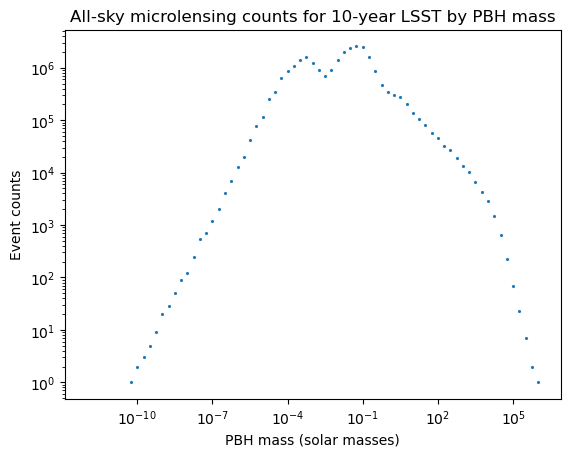

In [200]:
sns.lineplot(ratedf,x='pbhmass', y='rate', linestyle='None', marker='.')
plt.xlabel('PBH mass (solar masses)')
plt.ylabel('Event counts')
plt.xscale('log')
plt.yscale('log')
plt.title('All-sky microlensing counts for 10-year LSST by PBH mass')
# plt.savefig('/Users/duncan/Documents/code/physics/dissertation/ims/rubinsim/rates-mass-1000.pdf')

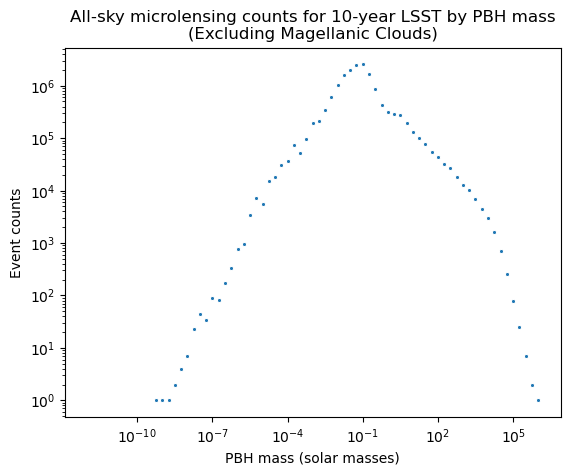

In [229]:
sns.lineplot(ratedf_mw,x='pbhmass', y='rate', linestyle='None', marker='.')
plt.xlabel('PBH mass (solar masses)')
plt.ylabel('Event counts')
plt.xscale('log')
plt.yscale('log')
plt.title('All-sky microlensing counts for 10-year LSST by PBH mass\n(Excluding Magellanic Clouds)')
plt.savefig('/Users/duncan/Documents/code/physics/dissertation/ims/rubinsim/rates-mass-1000-nomc.pdf')

Text(0.5, 1.0, 'All-sky microlensing counts for 10-year LSST by PBH mass')

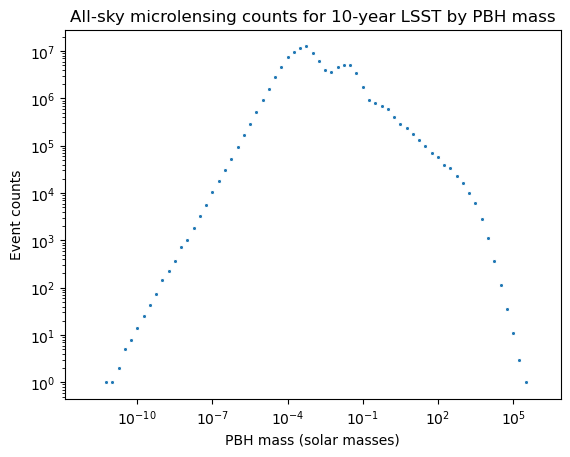

In [227]:
sns.lineplot(ratedf_mc,x='pbhmass', y='rate', linestyle='None', marker='.')
plt.xlabel('PBH mass (solar masses)')
plt.ylabel('Event counts')
plt.xscale('log')
plt.yscale('log')
plt.title('All-sky microlensing counts for 10-year LSST by PBH mass')
# plt.savefig('/Users/duncan/Documents/code/physics/dissertation/ims/rubinsim/rates-mass-1000.pdf')

<Axes: ylabel='Frequency'>

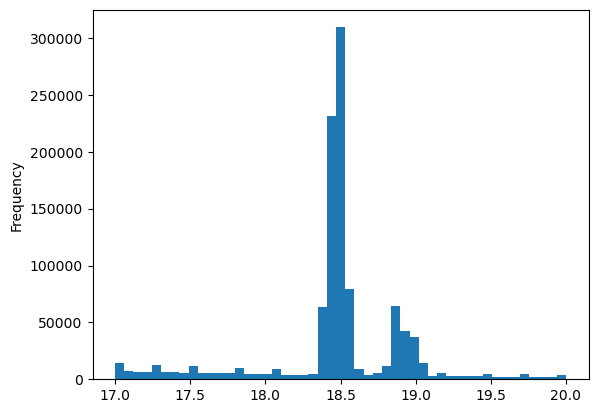

In [217]:
sources['mu0'].plot.hist(bins=np.linspace(17,20,50))